# The Muni-Treasury Ratio — does 'cheap munis' time the bond market? 🏛️
### Using the muni-vs-Treasury yield ratio as a rich/cheap dial, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Municipal bonds ('munis') pay interest that's exempt from federal income tax, so they can pay a *lower* yield than a Treasury and still leave a high-tax investor better off. The muni desk's oldest gauge is the **muni-Treasury ratio**: the muni yield divided by the Treasury yield. When that ratio is unusually **high**, munis look **cheap** (they're paying a big slice of the Treasury yield *despite* the tax break) and are supposed to outperform; when it's **low**, munis look **rich** and should lag.

So we test it the cheap way: take a muni ETF (**MUB**) and a Treasury ETF (**IEF**), build their yield ratio, and see whether a high ratio really does predict munis beating Treasuries over the next few months.

> 📓 **This is the plain-language layer.** Want the *t*-stats, the overlap trap and the cost maths? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from muni_treasury_ratio import data, strategy as st

WARMUP = "2009-06-30"    # drop the first year (trailing-yield warm-up)

def load_real():
    """Cache-first real analysis frame (empty offline)."""
    df = data.fetch_series(fetch=False)
    if df.empty:
        return pd.DataFrame()
    return df.loc[WARMUP:]

DF = load_real()
HAVE_REAL = not DF.empty
print("real MUB/IEF tape present:", HAVE_REAL,
      "" if not HAVE_REAL else f"({len(DF)} days, {DF.index.min().date()} -> {DF.index.max().date()})")


real MUB/IEF tape present: True (4275 days, 2009-06-30 -> 2026-06-29)


## The answer first 🎯

| Question | Answer |
|---|---|
| Do cheap munis (high ratio) really outperform next? | **Yes — in direction.** The cheapest-muni fifth of days earned **+0.51%** vs the richest fifth's **-0.09%** over the next 3 months — a **+0.6%** edge, the *right* way. |
| Is that a real, bankable signal? | **No.** Once you account for the fact that overlapping 3-month windows aren't independent, the *t*-stat falls from a shiny **+4.12** to just **+0.51**. The edge is inside the noise. |
| Does it work at other horizons? | **Same story** — right sign at 1, 3, 6, 12 months, but the honest *t* never clears 2 (best is +1.28 at a year). |
| Could you trade it? | **No.** A +0.35% net wobble that isn't statistically real, built on a coarse yield *proxy* rather than the curve a desk actually quotes. |

> The ratio leans the right way — but 'leans the right way' and 'is a signal you can bet on' are different things. The gap between them is what this study measures.

## 1 · The claim

> *"When the muni-Treasury yield ratio is high, munis are cheap and will outperform; when it's low, munis are rich and will lag."* — muni-desk folklore (the daily 10-year AAA-muni / Treasury ratio).

The intuition is genuinely sensible. Munis are tax-exempt, so in a fair world they'd yield roughly *(1 − your tax rate)* times a Treasury. If the ratio climbs well above that, munis are handing you extra yield for the same-ish risk — a bargain — and the price should eventually catch up (munis outperform). If it sinks, munis are expensive. It's a mean-reversion story dressed as relative value.

## 2 · So what?

If it worked, it'd be a clean dial: overweight munis when the ratio is high, underweight when low. But there's a catch baked into the claim — the ratio is **also a tax artifact**. It moves when people change their minds about future tax rates, not just when munis get cheap. So a 'high ratio' can mean 'bargain' *or* 'the market expects lower taxes' — and those imply opposite trades. The desk has looked at the Treasury *curve* as a timer ([132 Yield-Curve-Steepener](../../132-yield-curve-steepener/)); here we go at the muni-vs-Treasury *ratio*.

## 3 · How would we even know?

1. **Build the ratio.** Muni yield (from MUB's payouts) ÷ Treasury yield (from IEF's payouts), each day.
2. **Score cheap/rich.** Compare today's ratio to its own last year — a *high* z-score means munis look cheap versus recent history.
3. **Look forward.** Did munis beat Treasuries over the next 3 months when the ratio was high? Sort days into fifths by the ratio and compare.

Catch we'll hit hard: 3-month forward windows *overlap* — today's window shares 62 of its 63 days with yesterday's. That makes the data look like far more independent evidence than it is, and it's exactly how a nothing-signal can print a big *t*-stat.

*Timing:* the ratio uses only data up to today's close; we act at that close and hold forward. No peeking.

## 4 · The teardown — let's actually look

**Did the cheap-muni days really lead to muni outperformance?**

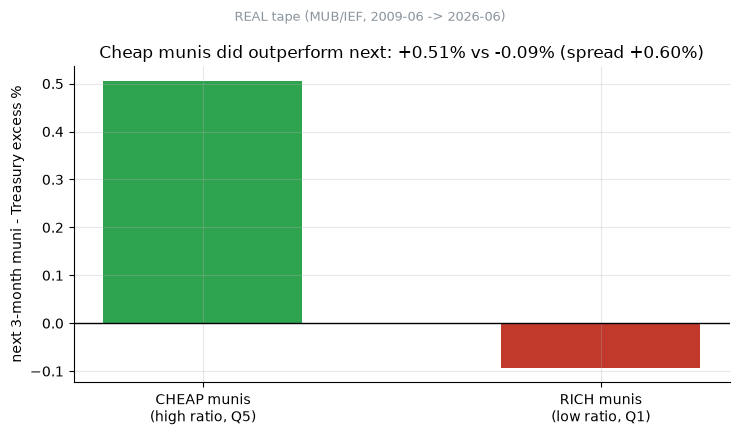

Q5 (cheap) +0.51%  vs  Q1 (rich) -0.09%  ->  spread +0.60%


In [2]:
if HAVE_REAL:
    b = st.quintile_spread(DF, 252, 63)
    q5, q1, spr = b['q5_mean']*100, b['q1_mean']*100, b['spread']*100
    banner = 'REAL tape (MUB/IEF, 2009-06 -> 2026-06)'
else:
    q5, q1, spr = 0.51, -0.09, 0.6
    banner = 'frozen real numbers (offline)'
fig, ax = plt.subplots(figsize=(7.5, 4.4))
ax.bar(['CHEAP munis\n(high ratio, Q5)','RICH munis\n(low ratio, Q1)'], [q5, q1],
       color=[GREEN, RED], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('next 3-month muni - Treasury excess %')
ax.set_title(f'Cheap munis did outperform next: +{q5:.2f}% vs {q1:.2f}% (spread +{spr:.2f}%)')
fig.suptitle(banner, fontsize=9, color=GREY); plt.tight_layout(); plt.show()
print(f'Q5 (cheap) +{q5:.2f}%  vs  Q1 (rich) {q1:+.2f}%  ->  spread {spr:+.2f}%')

There's the folklore, pointing the **right way**: the cheap-muni days (Q5) beat the rich-muni days (Q1) by **+0.6%** over the next quarter. On its own that looks like a win — and the naive *t*-stat is a juicy **+4.12**. So why isn't this a `REAL` signal?

**Because the windows overlap.** Watch what happens when we only use *non-overlapping* 3-month windows — genuinely independent bets, no shared days:

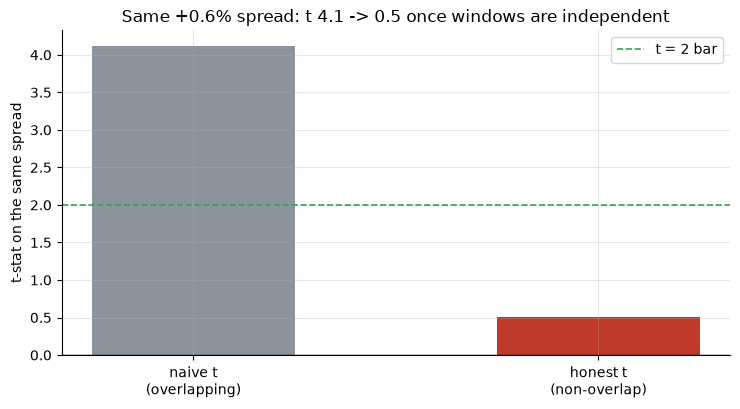

naive overlapping t +4.12  ->  honest non-overlap t +0.51 (n=65)


In [3]:
if HAVE_REAL:
    ss = st.spread_tstat(st.quintile_spread(DF, 252, 63))
    a = st.aligned(DF, 252, 63); sub = a.iloc[::63]
    z = sub['ratio_z'].values; y = sub['fwd_excess'].values
    hi = z >= np.quantile(z, 0.8); lo = z <= np.quantile(z, 0.2)
    va, vb = y[hi].var(ddof=1), y[lo].var(ddof=1)
    tt = (y[hi].mean()-y[lo].mean())/np.sqrt(va/hi.sum()+vb/lo.sum())
    naive_t, nonov_t, nn = ss['t'], tt, len(sub)
else:
    naive_t, nonov_t, nn = 4.12, 0.51, 65
SPR = 0.6
fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.bar(['naive t\n(overlapping)','honest t\n(non-overlap)'], [naive_t, nonov_t],
       color=[GREY, RED], width=.5)
ax.axhline(2, ls='--', c=GREEN, lw=1.2, label='t = 2 bar')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('t-stat on the same spread')
ax.set_title(f'Same +{SPR}% spread: t {naive_t:.1f} -> {nonov_t:.1f} once windows are independent')
ax.legend(); plt.tight_layout(); plt.show()
print(f'naive overlapping t {naive_t:+.2f}  ->  honest non-overlap t {nonov_t:+.2f} (n={nn})')

There's the trick. The **same** +0.6% spread carries a *t* of +4.12 when you let the windows overlap, but only **+0.51** on independent windows (just 65 of them). The overlap manufactured almost all the significance. The signal is real in *direction* but not in *strength*.

## 5 · The verdict

- **Signal — Weak.** Right sign at every horizon, literature behind it — but no honest *t* ≥ 2 on the tape (the overlap-corrected *t* is +0.5).
- **Tradability — Mirage.** A +0.35% net wobble that isn't statistically real, on a coarse yield proxy rather than the curve a desk trades.

## 6 · Could you actually trade it?

Not on this evidence. The edge clears trading costs on paper (+0.60% gross → +0.35% net), but it isn't statistically distinguishable from zero, and we built the ratio from ETF *payout* yields — a coarse stand-in for the AAA-muni / Treasury *par* curve a real muni desk quotes. Worse, the ratio is partly a **tax bet** (it moves with expected tax rates), so a 'cheap' reading can mean two opposite things. A dial you can't read cleanly isn't a dial.

## 7 · Going further 🚪

- **The Treasury-only cousin.** [132 Yield-Curve-Steepener](../../132-yield-curve-steepener/) times the long bond off the *curve slope* — same 'right sign, weak *t*' shape.
- **The real test needs the real curve.** Re-run this off MMD/AAA-GO muni yields vs matched-maturity Treasuries (not ETF payout proxies), and separate the tax-expectation component from the relative-value one.

*Think the ratio really times munis and we just used too coarse a proxy? Fork this, plug in the MMD curve, and show the muni-minus-Treasury spread clearing t = 2 on independent windows.*